# Resume Category Classification v3.2
**Dataset:** Kaggle *Resume Dataset* (`Resume/Resume.csv`): `ID, Resume_str, Resume_html, Category` (about 2,400 resumes, 24 categories).

**Results so far:** v1 LinearSVC 68.4% -> v2 (job-title features) 84.2% top-1, 94.1% top-3.

**v3.1 adds**
1. Extensive EDA (data quality, lengths, structure, titles, vocabulary, class separability, label-noise probe)
2. Sentence-embedding features combined with TF-IDF (skipped automatically if the model cannot be downloaded)
3. Error analysis, model comparison table and an end-to-end save/reload test on raw text
4. Optional DistilBERT fine-tuning (off by default, needs a GPU runtime)

v3.2 fixes: embeddings are forced onto the CPU (v3.1 crashed with `CUDA out of memory` on a busy Kaggle GPU and silently fell back to TF-IDF only); stale files from older runs are removed from `saved_model/`.

v3.1 fixes: works on old and new scikit-learn (`get_feature_names` vs `get_feature_names_out`), and the length-table cell bug.

Run with **Restart & Run All**. On Kaggle, turn **Internet ON** (Settings) so the embedding model can download.

## 0. Imports and configuration

In [134]:
import os, re, glob, json, warnings, sys
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50, "display.width", 200, "display.max_colwidth", 80)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25})

SEED = 42
np.random.seed(SEED)
SAVE_DIR = "saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- configuration ----
MIN_PER_CLASS = 30                 # classes with fewer resumes are dropped for modelling (BPO has 22). Use 10 to keep more.
HEAD_WORDS = 8                     # first N words = job title block
USE_EMBEDDINGS = True              # sentence embeddings (needs internet once to download the model)
EMBED_MODEL = "all-MiniLM-L6-v2"
EMBED_CHARS = 1500                 # first N characters of the raw resume are embedded
RUN_BERT = False                   # optional DistilBERT fine-tuning (section 19); needs GPU

def feat_names(vec):
    """Works on old (<1.0) and new scikit-learn versions."""
    if hasattr(vec, "get_feature_names_out"):
        return np.array(vec.get_feature_names_out())
    return np.array(vec.get_feature_names())

import sklearn
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| Config OK")

scikit-learn 0.23.2 | pandas 1.3.4 | Config OK


## 1. Load the dataset
Searches common locations for `Resume.csv`. Set `CSV_PATH` manually if needed.

In [135]:
CSV_PATH = None   # e.g. "/kaggle/input/resume-dataset/Resume/Resume.csv"

if CSV_PATH is None:
    patterns = [
        "/kaggle/input/**/Resume.csv", "../input/**/Resume.csv",
        "./Resume.csv", "./**/Resume.csv", "./data/**/Resume.csv",
        "/content/**/Resume.csv", "/content/drive/**/Resume.csv",
    ]
    found = []
    for p in patterns:
        found += glob.glob(p, recursive=True)
    found = [f for f in dict.fromkeys(found) if "saved_model" not in f]
    if not found:
        raise FileNotFoundError("Resume.csv not found. Set CSV_PATH in this cell to the file location.")
    CSV_PATH = found[0]

print("Using:", CSV_PATH)
df_raw = pd.read_csv(CSV_PATH)
df_raw.columns = df_raw.columns.str.strip()
print("Raw columns:", df_raw.columns.tolist())

df = df_raw.rename(columns={"Resume_str": "Resume"}) if "Resume_str" in df_raw.columns else df_raw.copy()
if not {"Category", "Resume"}.issubset(df.columns):
    raise ValueError(f"Expected Category and Resume_str/Resume columns, got {df.columns.tolist()}")

missing = df[["Category", "Resume"]].isna().sum()
df = df[["Category", "Resume"]].dropna().copy()
df["Category"] = df["Category"].astype(str).str.strip()
df["Raw"] = df["Resume"].astype(str)
df = df.drop(columns=["Resume"])
print("Missing values before dropping:\n", missing.to_string())
print("Rows loaded:", len(df))

Using: /kaggle/input/resume-dataset/Resume/Resume.csv
Raw columns: ['ID', 'Resume_str', 'Resume_html', 'Category']
Missing values before dropping:
 Category    0
Resume      0
Rows loaded: 2484


## 2. EDA part 1: data quality and class balance

In [136]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes.to_string())
n_dup = df.duplicated(subset="Raw").sum()
print(f"\nExact duplicate resumes: {n_dup}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nSample row:")
print(df.iloc[0]["Category"], "|", df.iloc[0]["Raw"][:400].replace("\n", " "))

Shape: (2484, 2)

Dtypes:
 Category    object
Raw         object

Exact duplicate resumes: 2
Memory: 38.3 MB

Sample row:
HR |          HR ADMINISTRATOR/MARKETING ASSOCIATE  HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team manageme


After removing exact duplicates: 2482
                        count  percent
INFORMATION-TECHNOLOGY    120     4.83
BUSINESS-DEVELOPMENT      120     4.83
ADVOCATE                  118     4.75
ACCOUNTANT                118     4.75
ENGINEERING               118     4.75
CHEF                      118     4.75
FINANCE                   117     4.71
FITNESS                   117     4.71
AVIATION                  116     4.67
SALES                     116     4.67
BANKING                   115     4.63
HEALTHCARE                115     4.63
CONSULTANT                115     4.63
CONSTRUCTION              112     4.51
PUBLIC-RELATIONS          111     4.47
HR                        110     4.43
DESIGNER                  107     4.31
ARTS                      103     4.15
TEACHER                   102     4.11
APPAREL                    97     3.91
DIGITAL-MEDIA              96     3.87
AGRICULTURE                63     2.54
AUTOMOBILE                 36     1.45
BPO                       

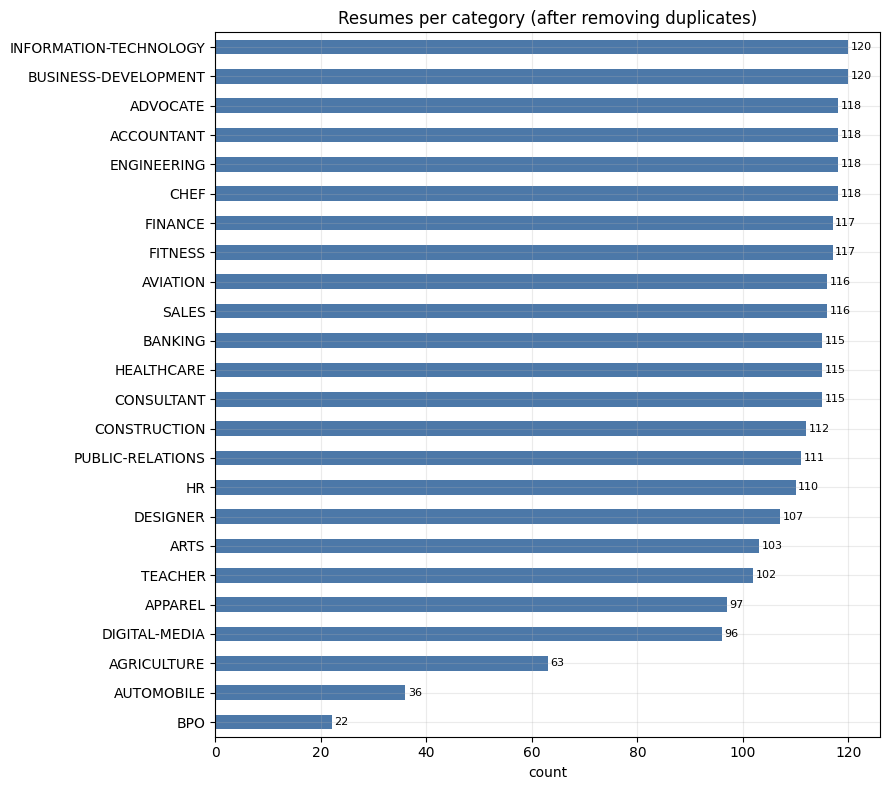

In [137]:
df = df.drop_duplicates(subset="Raw").reset_index(drop=True)
print("After removing exact duplicates:", len(df))

cls = df["Category"].value_counts()
cls_df = pd.DataFrame({"count": cls, "percent": (cls / cls.sum() * 100).round(2)})
print(cls_df.to_string())
print(f"\nClasses: {len(cls)} | largest/smallest ratio: {cls.max() / cls.min():.1f}x | median class size: {cls.median():.0f}")

fig, ax = plt.subplots(figsize=(9, 8))
cls.sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
for i, v in enumerate(cls.sort_values().values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=8)
ax.set_title("Resumes per category (after removing duplicates)")
ax.set_xlabel("count")
plt.tight_layout(); plt.show()

## 3. EDA part 2: resume length

       n_chars  n_words
count   2482.0   2482.0
mean    6296.0    811.0
std     2770.0    371.0
min       21.0      0.0
5%      2436.0    302.0
25%     5160.0    651.0
50%     5888.0    757.0
75%     7228.0    933.0
95%    10796.0   1399.0
99%    15916.0   2053.0
max    38842.0   5190.0

Very short (<100 words): 1 | very long (>2500 words): 16


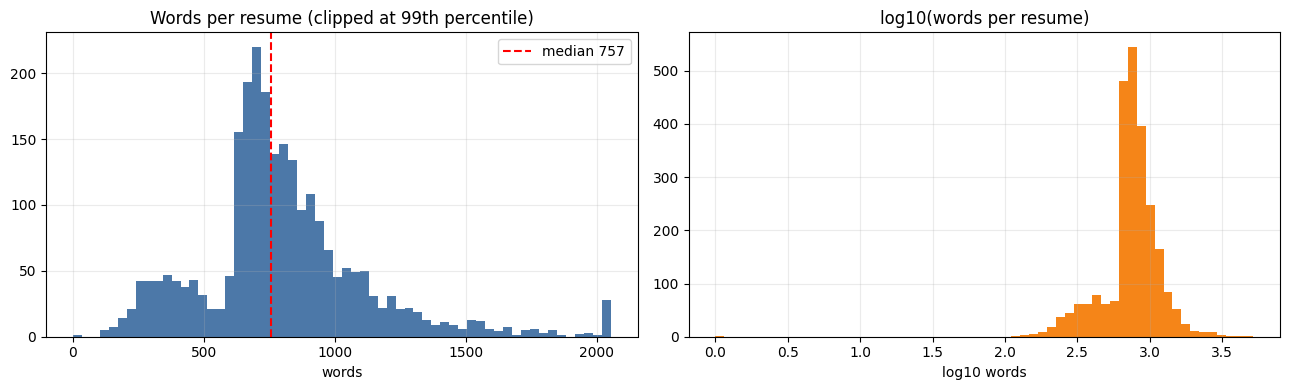

In [138]:
df["n_chars"] = df["Raw"].str.len()
df["n_words"] = df["Raw"].str.split().str.len()
print(df[["n_chars", "n_words"]].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(0).to_string())
print("\nVery short (<100 words):", int((df["n_words"] < 100).sum()), "| very long (>2500 words):", int((df["n_words"] > 2500).sum()))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(df["n_words"].clip(upper=df["n_words"].quantile(0.99)), bins=60, color="#4c78a8")
ax[0].axvline(df["n_words"].median(), color="red", ls="--", label=f"median {df['n_words'].median():.0f}")
ax[0].set_title("Words per resume (clipped at 99th percentile)"); ax[0].legend(); ax[0].set_xlabel("words")
ax[1].hist(np.log10(df["n_words"].clip(lower=1)), bins=60, color="#f58518")
ax[1].set_title("log10(words per resume)"); ax[1].set_xlabel("log10 words")
plt.tight_layout(); plt.show()

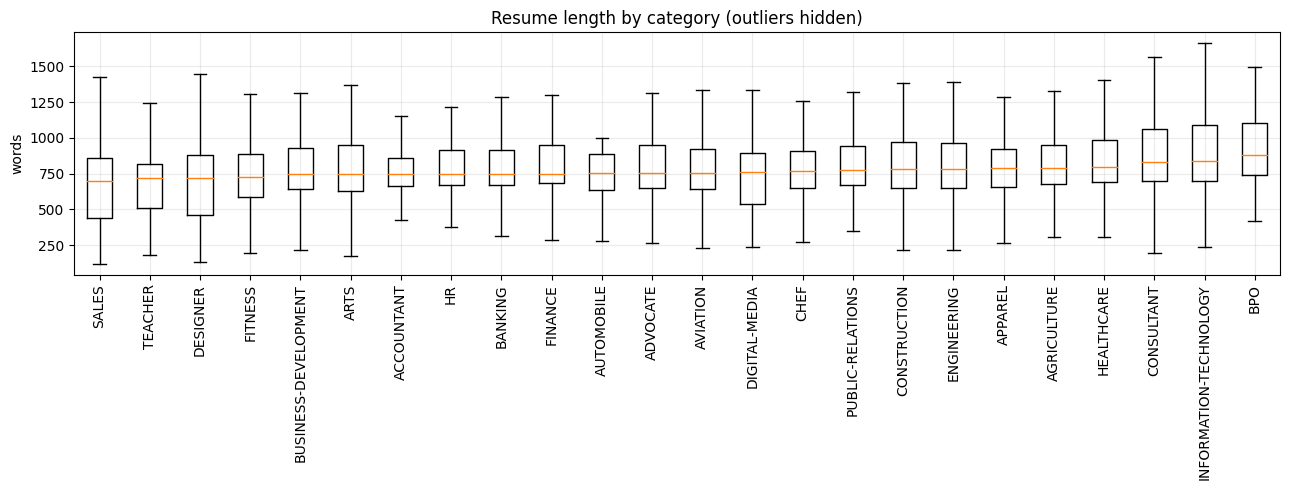

Shortest categories (median words):
                      median   mean  min   max
Category                                      
SALES                  696.0  690.0  122  2486
TEACHER                719.0  715.0  183  2694
DESIGNER               722.0  735.0  131  2284
FITNESS                725.0  723.0  199  1797
BUSINESS-DEVELOPMENT   746.0  775.0    0  1605

Longest categories:
                        median   mean  min   max
Category                                        
AGRICULTURE              793.0  856.0  192  1970
HEALTHCARE               794.0  882.0  242  2749
CONSULTANT               829.0  880.0  194  2018
INFORMATION-TECHNOLOGY   839.0  927.0  237  2670
BPO                      878.0  974.0  420  2310


In [139]:
order = df.groupby("Category")["n_words"].median().sort_values().index
data = [df.loc[df["Category"] == c, "n_words"].values for c in order]
plt.figure(figsize=(13, 5))
plt.boxplot(data, showfliers=False)
plt.xticks(range(1, len(order) + 1), order, rotation=90)
plt.ylabel("words")
plt.title("Resume length by category (outliers hidden)")
plt.tight_layout(); plt.show()

len_tbl = df.groupby("Category")["n_words"].agg(["median", "mean", "min", "max"]).round(0).sort_values("median")
print("Shortest categories (median words):")
print(len_tbl.head(5).to_string())
print("\nLongest categories:")
print(len_tbl.tail(5).to_string())

## 4. EDA part 3: resume structure
Which section headings appear, and do they differ by category?

Share of resumes (%) containing each section word:
skills                    99.0
education                 98.1
experience                96.9
summary                   76.6
professional              73.0
highlights                43.8
accomplishments           38.8
additional_information    19.1
qualifications            17.2
affiliations              16.0
certifications            15.9
objective                  4.3
references                 2.5


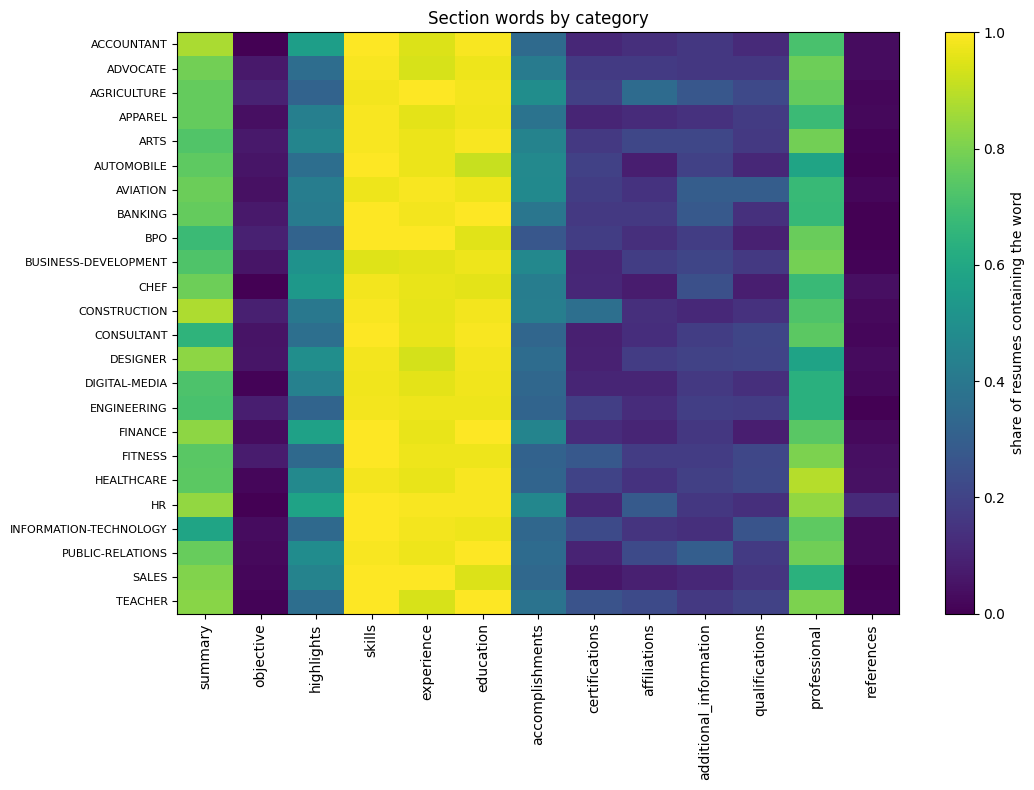

In [140]:
headings = ["summary", "objective", "highlights", "skills", "experience", "education", "accomplishments",
            "certifications", "affiliations", "additional information", "qualifications", "professional", "references"]
low = df["Raw"].str.lower()
has_cols = []
for h in headings:
    col = "has_" + h.replace(" ", "_")
    df[col] = low.str.contains(r"\b" + re.escape(h) + r"\b", regex=True)
    has_cols.append(col)

overall = df[has_cols].mean().sort_values(ascending=False)
print("Share of resumes (%) containing each section word:")
print((overall * 100).round(1).rename(lambda s: s[4:]).to_string())

by_cat = df.groupby("Category")[has_cols].mean()
by_cat.columns = [c[4:] for c in by_cat.columns]
plt.figure(figsize=(11, 8))
plt.imshow(by_cat.values, aspect="auto", cmap="viridis")
plt.xticks(range(by_cat.shape[1]), by_cat.columns, rotation=90)
plt.yticks(range(by_cat.shape[0]), by_cat.index, fontsize=8)
plt.colorbar(label="share of resumes containing the word")
plt.title("Section words by category"); plt.grid(False)
plt.tight_layout(); plt.show()

## 5. Text cleaning
The job title at the start of each resume is kept in place, because it turned out to be the strongest signal in v2.

In [141]:
STOP = set(ENGLISH_STOP_WORDS)

def preprocess(txt):
    txt = str(txt).lower()
    txt = re.sub(r"http\S+|www\.\S+", " ", txt)
    txt = re.sub(r"\S+@\S+", " ", txt)
    txt = re.sub(r"[^a-z\s]", " ", txt)
    tokens = [w for w in txt.split() if w not in STOP and len(w) > 1]
    return " ".join(tokens)

def head_of(text, n=HEAD_WORDS):
    return " ".join(text.split()[:n])

df["Clean"] = df["Raw"].apply(preprocess)
print("Empty after cleaning:", int((df["Clean"].str.strip() == "").sum()))
df = df[df["Clean"].str.strip() != ""].reset_index(drop=True)
df["n_tokens"] = df["Clean"].str.split().str.len()
print(f"Tokens per resume after cleaning: median {df['n_tokens'].median():.0f}, mean {df['n_tokens'].mean():.0f}")
print("\nBefore:", df['Raw'].iloc[0][:200].replace("\n", " "))
print("After: ", df['Clean'].iloc[0][:200])

Empty after cleaning: 1
Tokens per resume after cleaning: median 535, mean 572

Before:          HR ADMINISTRATOR/MARKETING ASSOCIATE  HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp
After:  hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused team


## 6. EDA part 4: job titles
The first words of a resume are usually the job title. How informative are they?

In [142]:
df["Title"] = df["Clean"].apply(head_of)
first_word = df["Clean"].str.split().str[0]
print("Most common first words overall:", Counter(first_word).most_common(15))

rows = []
for cat, g in df.groupby("Category"):
    top = Counter(w for t in g["Title"] for w in t.split()).most_common(6)
    rows.append((cat, ", ".join(f"{w}({n})" for w, n in top)))
print("\nMost frequent title-block words per category:")
print(pd.DataFrame(rows, columns=["Category", "top words in first %d tokens" % HEAD_WORDS]).to_string(index=False))

Most common first words overall: [('sales', 120), ('senior', 103), ('consultant', 93), ('business', 93), ('director', 92), ('hr', 90), ('engineering', 70), ('finance', 70), ('accountant', 66), ('information', 58), ('teacher', 55), ('construction', 48), ('assistant', 37), ('customer', 37), ('executive', 36)]

Most frequent title-block words per category:
              Category                                                                   top words in first 8 tokens
            ACCOUNTANT     accountant(163), summary(98), professional(53), years(27), experience(23), accounting(23)
              ADVOCATE        advocate(87), summary(84), professional(56), customer(27), service(21), experience(13)
           AGRICULTURE          summary(41), professional(27), research(13), experience(9), project(6), assistant(6)
               APPAREL             summary(65), professional(38), manager(35), assistant(11), sales(10), profile(10)
                  ARTS             summary(72), professiona

Overall: 67.8% of resumes contain a word from their own category name in the first 8 tokens


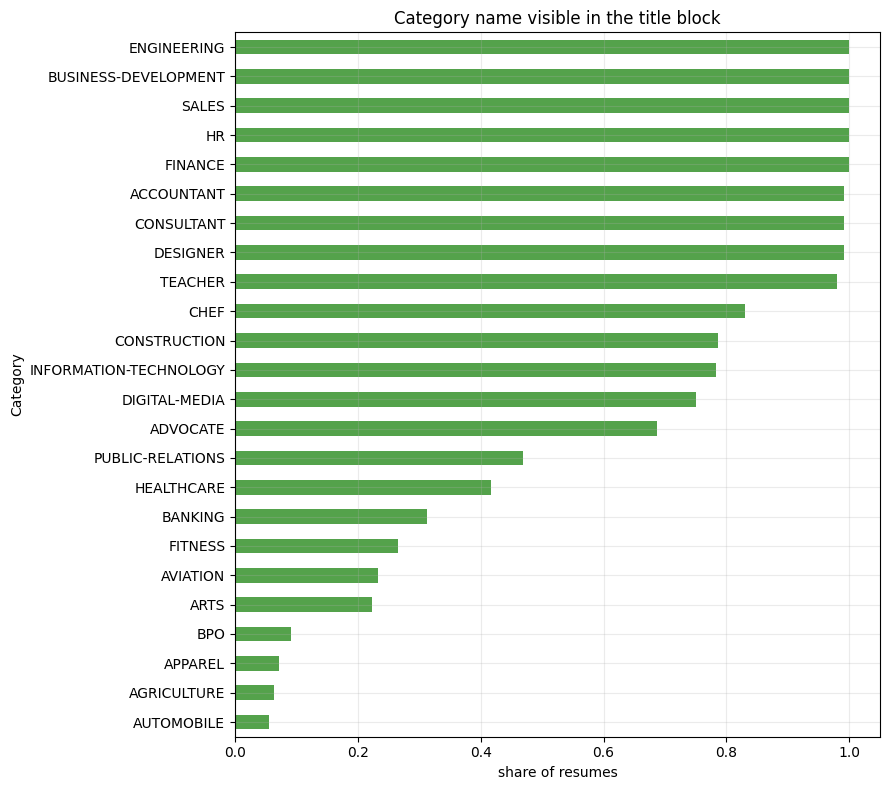


Examples of resumes with NO category cue in the title block (possible hard cases / label noise):
              Category                                                                            Title
              DESIGNER              zachory edmiston summary skilled customer service motivated enhance
               FITNESS                  personal trainer summary hard working seasoned customer service
                  CHEF                   summary kitchen manager years boh operations demonstrated team
INFORMATION-TECHNOLOGY     administrative assistant director human resources manager production manager
            CONSULTANT qualifications microsoft office specialist symantec endpoint protection symantec
               BANKING                           karla lee summary results focused people advocate vast
              ADVOCATE         summary administrative support professional experience working fast past
            ACCOUNTANT            summary years experience accounting 

In [143]:
def cat_tokens(cat):
    return [t for t in cat.lower().split("-") if len(t) > 1]

def title_hit(row):
    words = set(row["Title"].split())
    return any(t in words for t in cat_tokens(row["Category"]))

df["title_has_category_word"] = df.apply(title_hit, axis=1)
rate = df.groupby("Category")["title_has_category_word"].mean().sort_values()
print(f"Overall: {df['title_has_category_word'].mean() * 100:.1f}% of resumes contain a word from their own category name in the first {HEAD_WORDS} tokens")

plt.figure(figsize=(9, 8))
rate.plot(kind="barh", color="#54a24b")
plt.xlabel("share of resumes"); plt.title("Category name visible in the title block")
plt.tight_layout(); plt.show()

print("\nExamples of resumes with NO category cue in the title block (possible hard cases / label noise):")
no_cue = df[~df["title_has_category_word"]].groupby("Category").head(1)
print(no_cue.sample(min(8, len(no_cue)), random_state=SEED)[["Category", "Title"]].to_string(index=False))

## 7. EDA part 5: vocabulary

Total tokens: 1,418,792 | vocabulary: 37,238 | words seen once: 14,735 (39.6%)


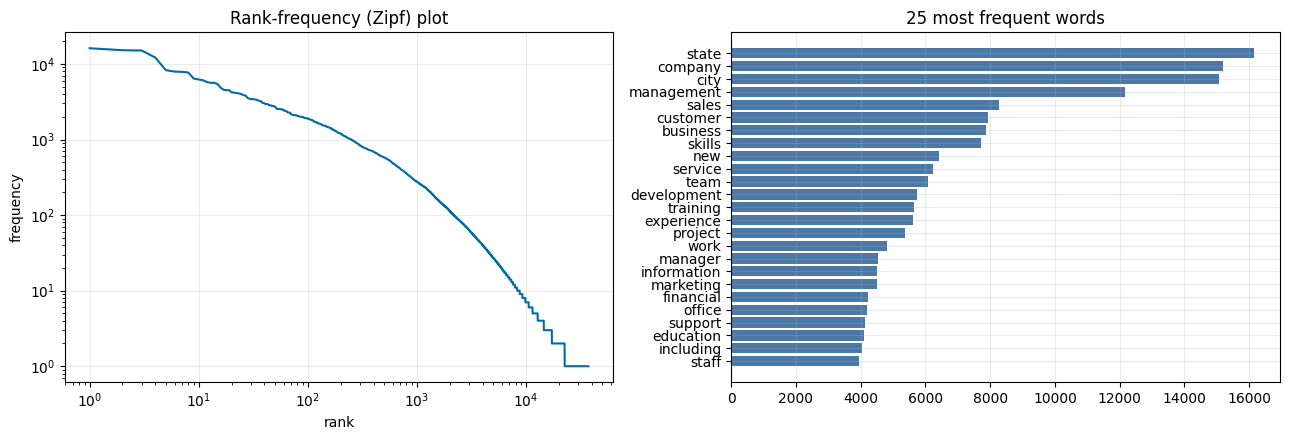


Words present in the most resumes (share of documents). These carry little class information:
company         100.0
skills           99.0
education        98.1
city             97.3
experience       96.9
state            96.7
management       85.4
summary          76.7
new              76.1
team             75.9
professional     73.0
work             71.2
current          71.1
university       69.7
training         69.4
service          66.4
customer         64.5
business         64.3
information      62.1
including        61.7


In [144]:
tok_counts = Counter(w for t in df["Clean"] for w in t.split())
V = len(tok_counts)
total = sum(tok_counts.values())
hapax = sum(1 for c in tok_counts.values() if c == 1)
print(f"Total tokens: {total:,} | vocabulary: {V:,} | words seen once: {hapax:,} ({hapax / V * 100:.1f}%)")

freqs = np.array(sorted(tok_counts.values(), reverse=True))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].loglog(np.arange(1, len(freqs) + 1), freqs)
ax[0].set_title("Rank-frequency (Zipf) plot"); ax[0].set_xlabel("rank"); ax[0].set_ylabel("frequency")
top = tok_counts.most_common(25)
ax[1].barh([w for w, _ in top][::-1], [c for _, c in top][::-1], color="#4c78a8")
ax[1].set_title("25 most frequent words")
plt.tight_layout(); plt.show()

cv = CountVectorizer(binary=True, min_df=5)
B = cv.fit_transform(df["Clean"])
docfreq = pd.Series(np.asarray(B.sum(axis=0)).ravel() / B.shape[0], index=feat_names(cv)).sort_values(ascending=False)
print("\nWords present in the most resumes (share of documents). These carry little class information:")
print((docfreq.head(20) * 100).round(1).to_string())

## 8. EDA part 6: what words define each category?

In [145]:
eda_vec = TfidfVectorizer(sublinear_tf=True, min_df=3, max_df=0.5)
Xe = eda_vec.fit_transform(df["Clean"])
terms = feat_names(eda_vec)
g_mean = np.asarray(Xe.mean(axis=0)).ravel()

cats_sorted = sorted(df["Category"].unique())
rows = []
for cat in cats_sorted:
    m = (df["Category"] == cat).values
    c_mean = np.asarray(Xe[m].mean(axis=0)).ravel()
    idx = np.argsort(-(c_mean - g_mean))[:10]
    rows.append((cat, ", ".join(terms[idx])))
print(pd.DataFrame(rows, columns=["Category", "most distinctive words (TF-IDF lift)"]).to_string(index=False))

              Category                                                                          most distinctive words (TF-IDF lift)
            ACCOUNTANT       accountant, accounting, ledger, accounts, entries, financial, reconciliations, tax, statements, payable
              ADVOCATE                              advocate, care, patient, patients, health, child, families, case, medical, court
           AGRICULTURE   agriculture, agricultural, extension, environmental, research, farmers, laboratory, soil, biological, plant
               APPAREL                apparel, merchandising, store, fashion, merchandise, product, inventory, retail, stores, floor
                  ARTS                    arts, students, teacher, student, parents, classroom, language, school, instruction, grade
            AUTOMOBILE                   automobile, claims, auto, police, vehicle, claim, inquiries, liability, property, insurance
              AVIATION                     aviation, aircraft, flight

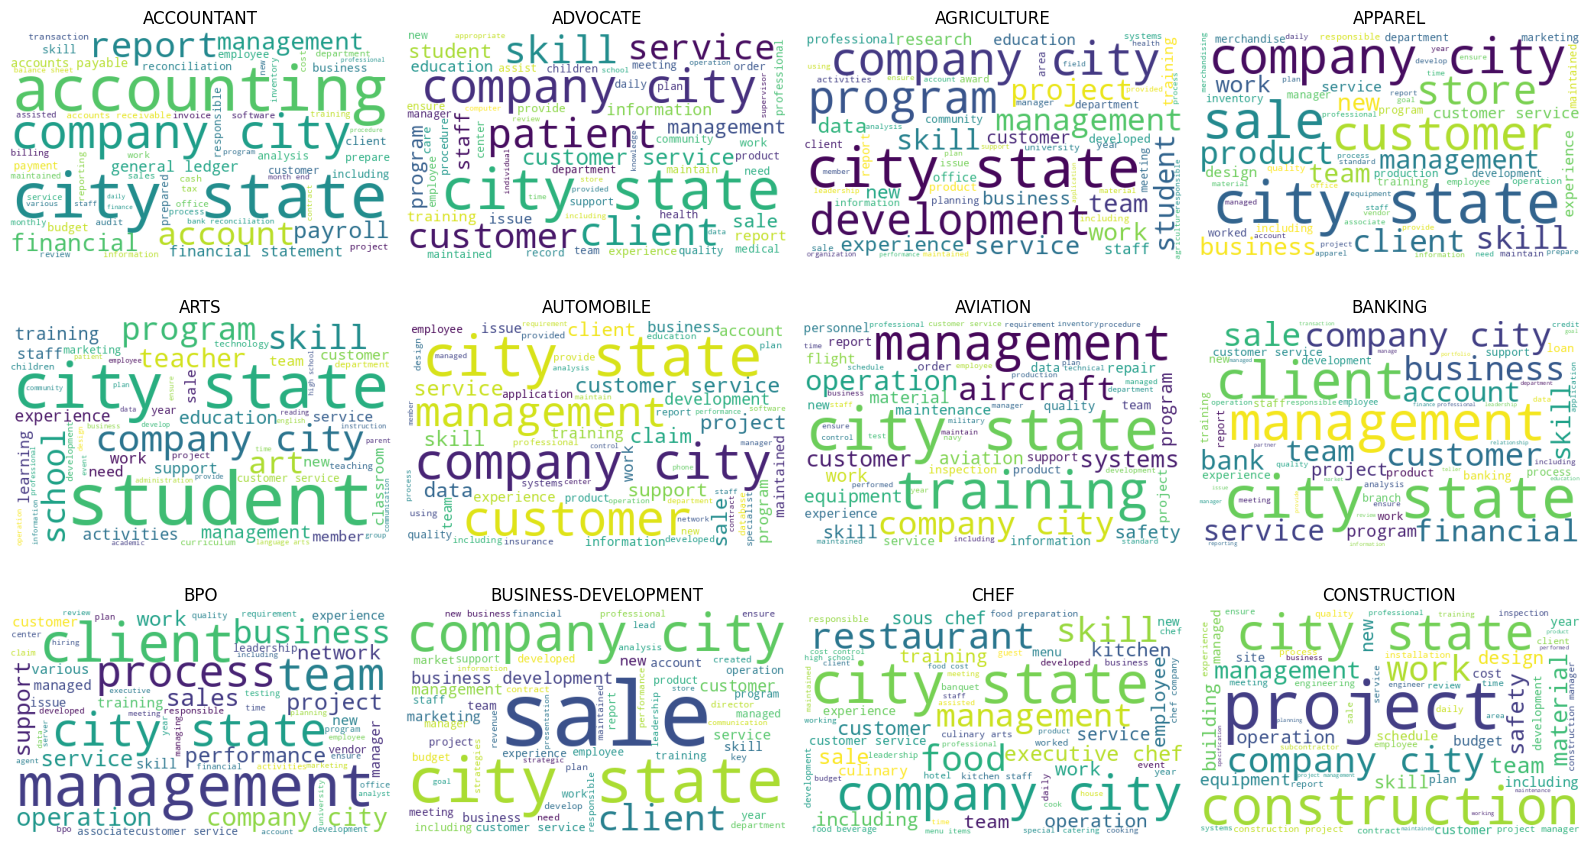

In [146]:
try:
    from wordcloud import WordCloud
    show = cats_sorted[:12]
    fig, axes = plt.subplots(3, 4, figsize=(16, 9))
    for ax, cat in zip(axes.ravel(), show):
        txt = " ".join(df.loc[df["Category"] == cat, "Clean"].sample(min(60, (df["Category"] == cat).sum()), random_state=SEED))
        ax.imshow(WordCloud(width=500, height=300, background_color="white", max_words=60).generate(txt))
        ax.set_title(cat); ax.axis("off")
    plt.tight_layout(); plt.show()
except ImportError:
    print("wordcloud not installed: skipping word clouds (pip install wordcloud)")

## 9. EDA part 7: how separable are the classes?

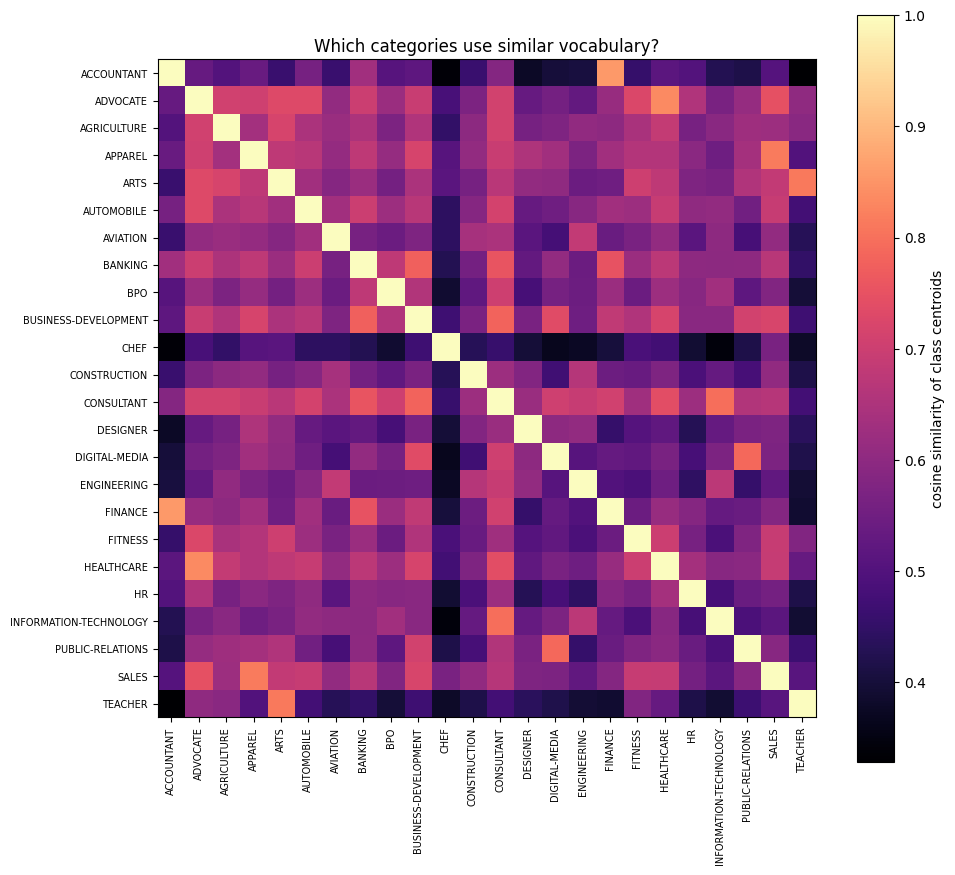

Most similar category pairs:
  0.858  ACCOUNTANT  <->  FINANCE
  0.837  ADVOCATE  <->  HEALTHCARE
  0.815  APPAREL  <->  SALES
  0.813  ARTS  <->  TEACHER
  0.798  CONSULTANT  <->  INFORMATION-TECHNOLOGY
  0.788  DIGITAL-MEDIA  <->  PUBLIC-RELATIONS
  0.781  BUSINESS-DEVELOPMENT  <->  CONSULTANT
  0.777  BANKING  <->  BUSINESS-DEVELOPMENT
  0.756  BANKING  <->  CONSULTANT
  0.753  BANKING  <->  FINANCE
  0.747  ADVOCATE  <->  SALES
  0.742  CONSULTANT  <->  HEALTHCARE


In [147]:
cats = np.array(cats_sorted)
cent = np.vstack([np.asarray(Xe[(df["Category"] == c).values].mean(axis=0)).ravel() for c in cats])
cent = normalize(cent)
sim = cent @ cent.T

plt.figure(figsize=(10, 9))
plt.imshow(sim, cmap="magma"); plt.grid(False)
plt.xticks(range(len(cats)), cats, rotation=90, fontsize=7)
plt.yticks(range(len(cats)), cats, fontsize=7)
plt.colorbar(label="cosine similarity of class centroids")
plt.title("Which categories use similar vocabulary?")
plt.tight_layout(); plt.show()

pairs = [(sim[i, j], cats[i], cats[j]) for i in range(len(cats)) for j in range(i + 1, len(cats))]
print("Most similar category pairs:")
for s, a, b in sorted(pairs, reverse=True)[:12]:
    print(f"  {s:.3f}  {a}  <->  {b}")

Explained variance of the 2 components: [0.004 0.012]
(Very low values mean a 2D plot keeps little of the structure: use it only as a rough picture.)


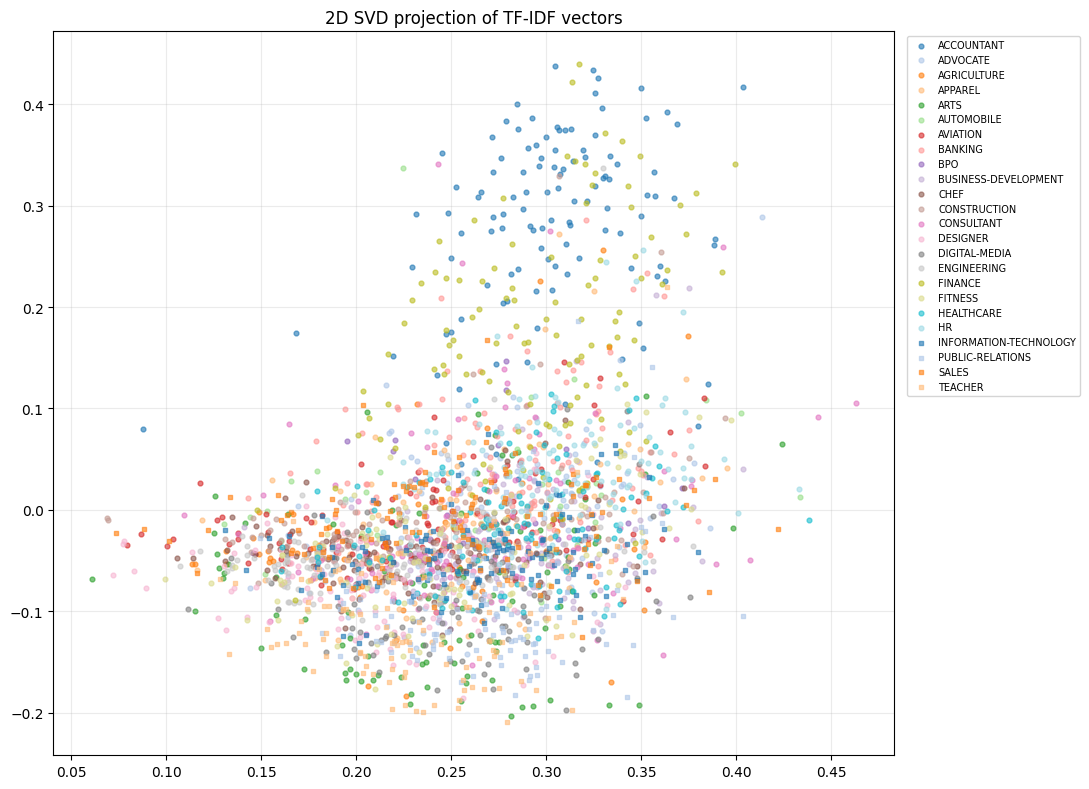

In [148]:
svd = TruncatedSVD(n_components=2, random_state=SEED)
Z = svd.fit_transform(Xe)
print("Explained variance of the 2 components:", svd.explained_variance_ratio_.round(4))
print("(Very low values mean a 2D plot keeps little of the structure: use it only as a rough picture.)")

cmap = plt.get_cmap("tab20")
markers = ["o", "s", "^", "v", "D", "P"]
plt.figure(figsize=(11, 8))
for i, c in enumerate(cats):
    m = (df["Category"] == c).values
    plt.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.6, color=cmap(i % 20), marker=markers[i // 20 % len(markers)], label=c)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, ncol=1)
plt.title("2D SVD projection of TF-IDF vectors")
plt.tight_layout(); plt.show()

## 10. EDA part 8: label-noise probe
5-fold cross-validated predictions on the **whole** dataset (EDA only, not used for the final evaluation). Resumes that are confidently predicted as another class are either hard or mislabelled.

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

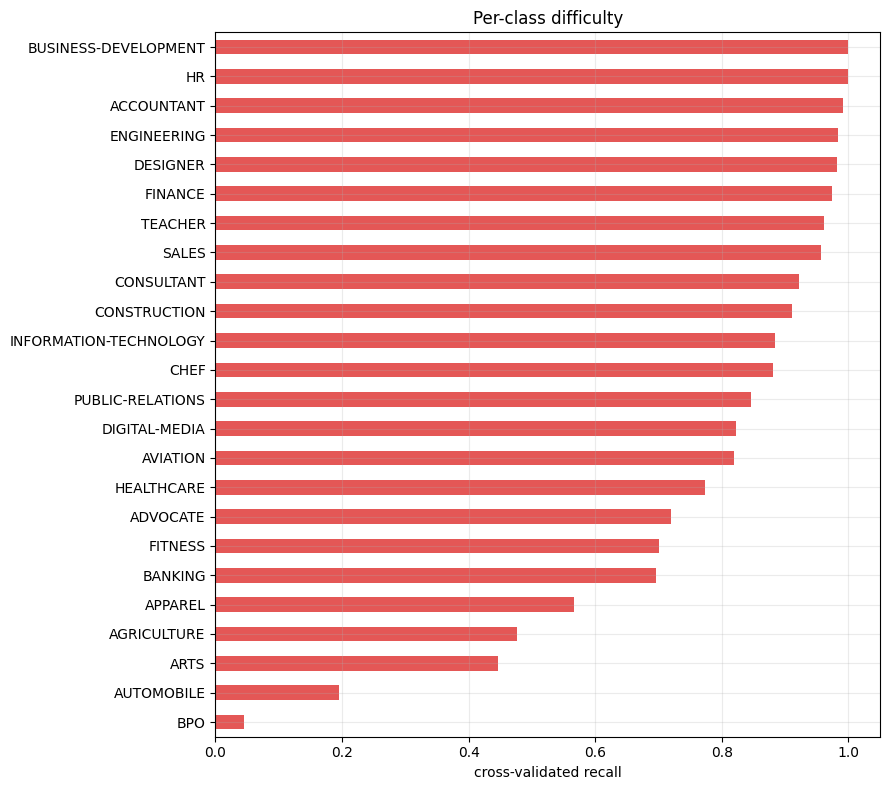


Most suspicious rows (model confident the label is different):
                 given           model says                                                                                title
            AUTOMOBILE           ACCOUNTANT accountant summary experienced accounting professional proficient analytical problem
           AGRICULTURE              TEACHER             lead teacher professional summary seeking education coordinator position
                  ARTS                 CHEF                                sous chef line cook summary quality focused efficient
               APPAREL             DESIGNER                              owner senior graphic designer ux designer app developer
               FITNESS                SALES                    sales associate summary customer service oriented associate years
         DIGITAL-MEDIA                   HR               sr leave administrative specialist professional summary hr coordinator
              ADVOCATE           

In [149]:
probe_body = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=60000).fit_transform(df["Clean"])
probe_head = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2)).fit_transform(df["Title"])
Xp = hstack([probe_body, probe_head]).tocsr()
yp_le = LabelEncoder().fit(df["Category"])
yp = yp_le.transform(df["Category"])

skf_probe = StratifiedKFold(5, shuffle=True, random_state=SEED)
scores = cross_val_predict(LinearSVC(class_weight="balanced", C=1, random_state=SEED), Xp, yp, cv=skf_probe, method="decision_function", n_jobs=-1)
pred_p = scores.argmax(axis=1)
print(f"Cross-validated accuracy on all data: {accuracy_score(yp, pred_p):.4f}")

per_cls = pd.Series({c: float(np.mean(pred_p[yp == i] == i)) for i, c in enumerate(yp_le.classes_)}).sort_values()
plt.figure(figsize=(9, 8))
per_cls.plot(kind="barh", color="#e45756")
plt.xlabel("cross-validated recall"); plt.title("Per-class difficulty")
plt.tight_layout(); plt.show()

margin = scores[np.arange(len(yp)), pred_p] - scores[np.arange(len(yp)), yp]
wrong = np.where(pred_p != yp)[0]
sus = wrong[np.argsort(-margin[wrong])][:15]
print("\nMost suspicious rows (model confident the label is different):")
print(pd.DataFrame({"given": yp_le.classes_[yp[sus]], "model says": yp_le.classes_[pred_p[sus]],
                    "title": df["Title"].values[sus]}).to_string(index=False))

pair_counts = Counter((yp_le.classes_[a], yp_le.classes_[b]) for a, b in zip(yp[wrong], pred_p[wrong]))
print("\nMost common confusions (true -> predicted):")
for (a, b), n in pair_counts.most_common(12):
    print(f"  {n:3d}  {a} -> {b}")

## 11. Drop tiny classes, encode labels, split
Split by row index so the same rows are used for TF-IDF features, embeddings and the raw text.

In [150]:
vc = df["Category"].value_counts()
keep = vc[vc >= MIN_PER_CLASS].index
dropped = sorted(set(vc.index) - set(keep))
if dropped:
    print("Dropping small classes:", dropped)
df = df[df["Category"].isin(keep)].reset_index(drop=True)

le = LabelEncoder()
y_all = le.fit_transform(df["Category"])
NUM_CLASSES = len(le.classes_)
print("Num classes:", NUM_CLASSES)

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=y_all, shuffle=True)
y_train, y_test = y_all[idx_train], y_all[idx_test]
X_train_txt, X_test_txt = df["Clean"].values[idx_train], df["Clean"].values[idx_test]
print(len(idx_train), "train /", len(idx_test), "test")

Dropping small classes: ['BPO']
Num classes: 23
1967 train / 492 test


## 12. TF-IDF features: body + job title

In [151]:
body_vec = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=60000)
head_vec = TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2), min_df=1)

Xb_tr = body_vec.fit_transform(X_train_txt)
Xb_te = body_vec.transform(X_test_txt)
Xh_tr = head_vec.fit_transform([head_of(t) for t in X_train_txt])
Xh_te = head_vec.transform([head_of(t) for t in X_test_txt])

def build_X(Xb, Xh, E, w, alpha):
    parts = [Xb, Xh * w]
    if E is not None and alpha > 0:
        parts.append(csr_matrix(E * alpha))
    return hstack(parts).tocsr()

print("Body:", Xb_tr.shape, "| Title:", Xh_tr.shape)

Body: (1967, 60000) | Title: (1967, 9348)


## 13. Sentence-embedding features
Embeds the first part of each raw resume with a pretrained model. If the model cannot be loaded (no internet), this section is skipped and the notebook continues with TF-IDF only.

In [152]:
def embed_text(raw):
    return " ".join(str(raw).split())[:EMBED_CHARS]

E_tr = E_te = None
embedder = None
if USE_EMBEDDINGS:
    try:
        try:
            from sentence_transformers import SentenceTransformer
        except ImportError:
            import subprocess
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"], check=True)
            from sentence_transformers import SentenceTransformer
        embedder = SentenceTransformer(EMBED_MODEL, device="cpu")   # CPU: avoids CUDA out-of-memory on shared GPUs
        embedder.max_seq_length = 256
        raw_all = [embed_text(t) for t in df["Raw"]]
        E_all = embedder.encode(raw_all, batch_size=32, show_progress_bar=False, normalize_embeddings=True)
        E_all = np.asarray(E_all, dtype="float32")
        E_tr, E_te = E_all[idx_train], E_all[idx_test]
        print("Embeddings:", E_all.shape)
    except Exception as e:
        print("Embeddings unavailable, continuing with TF-IDF only. Reason:", repr(e)[:200])
        embedder = None
        E_tr = E_te = None
else:
    print("USE_EMBEDDINGS is False")
HAVE_EMB = E_tr is not None
print("Embeddings in use:", HAVE_EMB)

Embeddings: (2459, 384)
Embeddings in use: True


## 14. Model selection (cross-validation on the training set only)

In [153]:
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
C_GRID = [0.1, 0.3, 1, 3]

def tune_svc(Xtr):
    gs = GridSearchCV(LinearSVC(class_weight="balanced", random_state=SEED), {"C": C_GRID},
                      cv=skf, scoring="f1_macro", n_jobs=-1)
    gs.fit(Xtr, y_train)
    return gs.best_score_, gs.best_params_["C"], gs.best_estimator_

best_tfidf = (-1, None, None, None)
for w in [0.0, 0.5, 1.0, 1.5, 2.0]:
    s, C, est = tune_svc(build_X(Xb_tr, Xh_tr, None, w, 0))
    print(f"TF-IDF only | title weight {w}: CV macro-F1 {s:.4f} (C={C})")
    if s > best_tfidf[0]:
        best_tfidf = (s, w, C, est)
cv_tfidf, best_w, _, svc_tfidf = best_tfidf

candidates = {"LinearSVC TF-IDF": dict(cv=cv_tfidf, clf=svc_tfidf, w=best_w, alpha=0.0)}

if HAVE_EMB:
    best_emb = (-1, None, None, None)
    for alpha in [0.5, 1.0, 2.0, 3.0]:
        s, C, est = tune_svc(build_X(Xb_tr, Xh_tr, E_tr, best_w, alpha))
        print(f"TF-IDF + embeddings | embedding weight {alpha}: CV macro-F1 {s:.4f} (C={C})")
        if s > best_emb[0]:
            best_emb = (s, alpha, C, est)
    cv_emb, best_alpha, _, svc_emb = best_emb
    candidates["LinearSVC TF-IDF+Emb"] = dict(cv=cv_emb, clf=svc_emb, w=best_w, alpha=best_alpha)

    Xtr_lr = build_X(Xb_tr, Xh_tr, E_tr, best_w, best_alpha)
    lr = LogisticRegression(C=20, max_iter=1000, class_weight="balanced")
    lr_cv = cross_val_score(lr, Xtr_lr, y_train, cv=skf, scoring="f1_macro", n_jobs=-1).mean()
    print(f"LogisticRegression TF-IDF+Emb: CV macro-F1 {lr_cv:.4f}")
    candidates["LogReg TF-IDF+Emb"] = dict(cv=lr_cv, clf=lr.fit(Xtr_lr, y_train), w=best_w, alpha=best_alpha)

best_name = max(candidates, key=lambda k: candidates[k]["cv"])
best = candidates[best_name]
best_clf, best_w, best_alpha = best["clf"], best["w"], best["alpha"]
print("\nChosen by cross-validation:", best_name, "| title weight:", best_w, "| embedding weight:", best_alpha)
pd.DataFrame({k: {"CV macro-F1": round(v["cv"], 4)} for k, v in candidates.items()}).T

TF-IDF only | title weight 0.0: CV macro-F1 0.6508 (C=3)
TF-IDF only | title weight 0.5: CV macro-F1 0.7635 (C=3)
TF-IDF only | title weight 1.0: CV macro-F1 0.7733 (C=1)
TF-IDF only | title weight 1.5: CV macro-F1 0.7526 (C=0.3)
TF-IDF only | title weight 2.0: CV macro-F1 0.7350 (C=3)
TF-IDF + embeddings | embedding weight 0.5: CV macro-F1 0.7690 (C=3)
TF-IDF + embeddings | embedding weight 1.0: CV macro-F1 0.7669 (C=3)
TF-IDF + embeddings | embedding weight 2.0: CV macro-F1 0.7509 (C=1)
TF-IDF + embeddings | embedding weight 3.0: CV macro-F1 0.7275 (C=0.3)
LogisticRegression TF-IDF+Emb: CV macro-F1 0.7645

Chosen by cross-validation: LinearSVC TF-IDF | title weight: 1.0 | embedding weight: 0.0


,CV macro-F1
LinearSVC TF-IDF,0.7733
LinearSVC TF-IDF+Emb,0.7690
LogReg TF-IDF+Emb,0.7645


## 15. Final evaluation on the held-out test set

In [154]:
USE_EMB_FINAL = HAVE_EMB and best_alpha > 0
Xtr_f = build_X(Xb_tr, Xh_tr, E_tr if USE_EMB_FINAL else None, best_w, best_alpha)
Xte_f = build_X(Xb_te, Xh_te, E_te if USE_EMB_FINAL else None, best_w, best_alpha)

def topk_accuracy(clf, X, y, k=3):
    topk = np.argsort(-clf.decision_function(X), axis=1)[:, :k]
    return float(np.mean([yy in row for yy, row in zip(y, topk)]))

test_rows = []
for name, v in candidates.items():
    use_e = HAVE_EMB and v["alpha"] > 0
    Xt = build_X(Xb_te, Xh_te, E_te if use_e else None, v["w"], v["alpha"])
    p = v["clf"].predict(Xt)
    test_rows.append((name, round(v["cv"], 4), round(accuracy_score(y_test, p), 4),
                      round(topk_accuracy(v["clf"], Xt, y_test, 3), 4), round(f1_score(y_test, p, average="macro"), 4)))
results_tbl = pd.DataFrame(test_rows, columns=["model", "CV macro-F1", "test top-1", "test top-3", "test macro-F1"])
print(results_tbl.to_string(index=False))

pred = best_clf.predict(Xte_f)
print(f"\nChosen model: {best_name}")
print(f"Test accuracy (top-1): {accuracy_score(y_test, pred):.4f}")
print(f"Test accuracy (top-3): {topk_accuracy(best_clf, Xte_f, y_test, 3):.4f}")
print(f"Test macro F1:         {f1_score(y_test, pred, average='macro'):.4f}\n")
print(classification_report(y_test, pred, labels=list(range(NUM_CLASSES)), target_names=le.classes_, zero_division=0))

               model  CV macro-F1  test top-1  test top-3  test macro-F1
    LinearSVC TF-IDF       0.7733      0.8415      0.9411         0.8143
LinearSVC TF-IDF+Emb       0.7690      0.8537      0.9350         0.8292
   LogReg TF-IDF+Emb       0.7645      0.8435      0.9309         0.8217

Chosen model: LinearSVC TF-IDF
Test accuracy (top-1): 0.8415
Test accuracy (top-3): 0.9411
Test macro F1:         0.8143

                        precision    recall  f1-score   support

            ACCOUNTANT       0.89      1.00      0.94        24
              ADVOCATE       0.83      0.83      0.83        24
           AGRICULTURE       0.88      0.54      0.67        13
               APPAREL       0.64      0.37      0.47        19
                  ARTS       0.71      0.57      0.63        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.87      0.87      0.87        23
               BANKING       0.80      0.70      0.74        23
  BUSINE

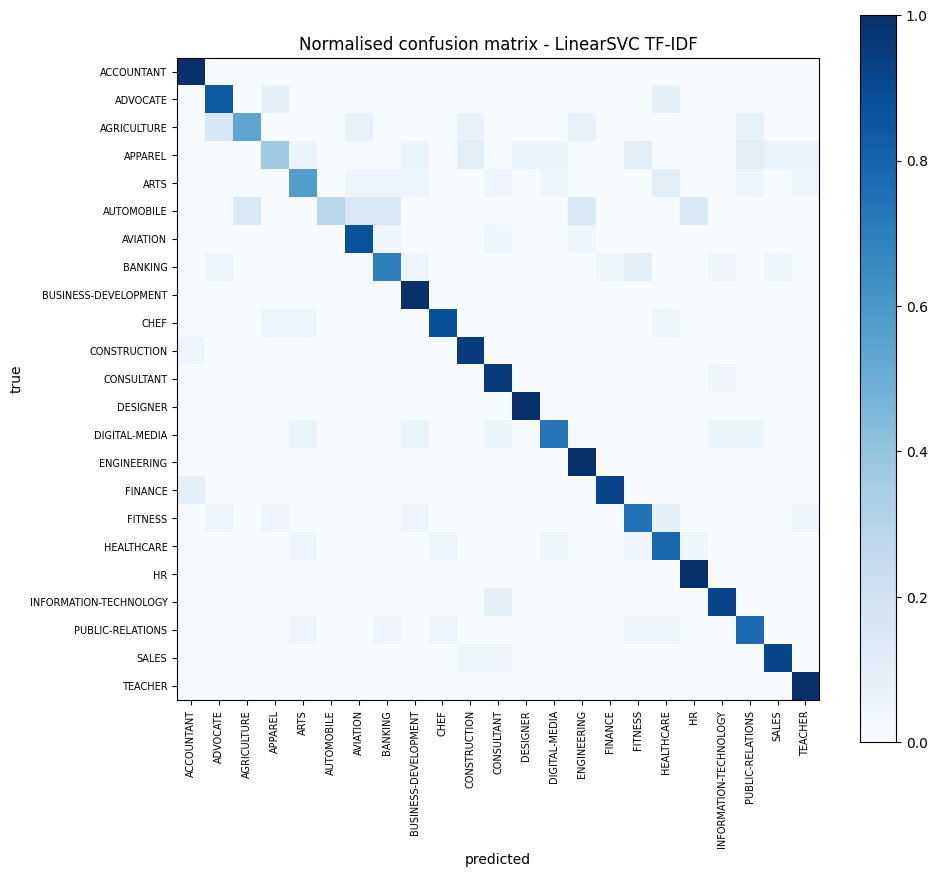

In [155]:
cm = confusion_matrix(y_test, pred, labels=list(range(NUM_CLASSES)))
cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(10, 9))
plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1); plt.grid(False)
plt.xticks(range(NUM_CLASSES), le.classes_, rotation=90, fontsize=7)
plt.yticks(range(NUM_CLASSES), le.classes_, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title(f"Normalised confusion matrix - {best_name}")
plt.colorbar(); plt.tight_layout(); plt.show()

## 16. Error analysis

In [156]:
wrong = np.where(pred != y_test)[0]
print(f"{len(wrong)} of {len(y_test)} test resumes misclassified")

pairs = Counter((le.classes_[y_test[i]], le.classes_[pred[i]]) for i in wrong)
print("\nTop confusions (true -> predicted):")
for (a, b), n in pairs.most_common(12):
    print(f"  {n:3d}  {a} -> {b}")

err_df = pd.DataFrame({"true": le.classes_[y_test[wrong]], "predicted": le.classes_[pred[wrong]],
                       "title": [head_of(X_test_txt[i]) for i in wrong]})
print("\nSample of errors:")
print(err_df.sample(min(15, len(err_df)), random_state=SEED).to_string(index=False))

nw = df["n_words"].values[idx_test]
bins = pd.qcut(nw, 4, duplicates="drop")
acc_by_len = pd.Series(pred == y_test).groupby(bins).mean()
print("\nAccuracy by resume length quartile (words):")
print(acc_by_len.round(3).to_string())

78 of 492 test resumes misclassified

Top confusions (true -> predicted):
    2  FITNESS -> HEALTHCARE
    2  ADVOCATE -> APPAREL
    2  APPAREL -> FITNESS
    2  AGRICULTURE -> ADVOCATE
    2  BANKING -> FITNESS
    2  APPAREL -> PUBLIC-RELATIONS
    2  ARTS -> HEALTHCARE
    2  INFORMATION-TECHNOLOGY -> CONSULTANT
    2  FINANCE -> ACCOUNTANT
    2  ADVOCATE -> HEALTHCARE
    2  APPAREL -> CONSTRUCTION
    1  AUTOMOBILE -> AVIATION

Sample of errors:
            true  predicted                                                                                  title
PUBLIC-RELATIONS    BANKING      manager professional summary talented individual educational background economics
         FITNESS HEALTHCARE            clinical study coordinator ii professional background clinical professional
            ARTS   AVIATION                    senior network security engineer professional summary overall years
      HEALTHCARE    FITNESS             certified personal trainer professional sum

## 17. Save the best model
The classifier, vectorizers, weights and labels are saved together. If embeddings are used, the embedding model name is stored so it can be reloaded.

In [157]:
for stale in ["tfidf_vectorizer.joblib", "tfidf_vectorizers.joblib", "keras_meta.json", "keras_tokenizer.json", "resume_bilstm.keras"]:
    p = f"{SAVE_DIR}/{stale}"
    if os.path.isfile(p):
        os.remove(p)   # leftovers from older notebook versions
joblib.dump(best_clf, f"{SAVE_DIR}/sk_classifier.joblib")
joblib.dump({"body": body_vec, "head": head_vec, "w": best_w, "alpha": best_alpha if USE_EMB_FINAL else 0.0,
             "head_words": HEAD_WORDS, "use_embed": bool(USE_EMB_FINAL),
             "embed_model": EMBED_MODEL, "embed_chars": EMBED_CHARS},
            f"{SAVE_DIR}/vectorizers.joblib")
with open(f"{SAVE_DIR}/labels.json", "w") as f:
    json.dump([str(c) for c in le.classes_], f)
print("Saved:", sorted(os.listdir(SAVE_DIR)))

Saved: ['labels.json', 'sk_classifier.joblib', 'vectorizers.joblib']


## 18. Reload from disk and test end to end on raw text
Only saved files plus `preprocess`, `head_of`, `embed_text` and `build_X` are used. The reloaded model must reproduce the test accuracy above.

In [158]:
sk_clf = joblib.load(f"{SAVE_DIR}/sk_classifier.joblib")
cfg = joblib.load(f"{SAVE_DIR}/vectorizers.joblib")
labels = json.load(open(f"{SAVE_DIR}/labels.json"))

loaded_embedder = None
if cfg["use_embed"]:
    from sentence_transformers import SentenceTransformer
    loaded_embedder = SentenceTransformer(cfg["embed_model"], device="cpu")
    loaded_embedder.max_seq_length = 256

def featurize_raw(raw_texts):
    clean = [preprocess(t) for t in raw_texts]
    Xb = cfg["body"].transform(clean)
    Xh = cfg["head"].transform([head_of(t, cfg["head_words"]) for t in clean])
    E = None
    if cfg["use_embed"]:
        E = np.asarray(loaded_embedder.encode([embed_text(t) for t in raw_texts], batch_size=32,
                                              show_progress_bar=False, normalize_embeddings=True), dtype="float32")
    return build_X(Xb, Xh, E, cfg["w"], cfg["alpha"])

def predict_resume(raw_text, top_k=3):
    scores = sk_clf.decision_function(featurize_raw([raw_text]))[0]
    idx = np.argsort(-scores)[:top_k]
    return [(labels[int(i)], round(float(scores[i]), 3)) for i in idx]

test_raw = df["Raw"].values[idx_test]
print("True:", labels[int(y_test[0])], "| Top-3:", predict_resume(test_raw[0]))
reloaded_pred = sk_clf.predict(featurize_raw(list(test_raw)))
print("Reloaded model test accuracy on RAW text:", round(float(np.mean(reloaded_pred == y_test)), 4))
print("In-memory test accuracy:                 ", round(float(accuracy_score(y_test, pred)), 4))

True: ADVOCATE | Top-3: [('ADVOCATE', 0.695), ('HR', -0.413), ('AUTOMOBILE', -0.982)]
Reloaded model test accuracy on RAW text: 0.8415
In-memory test accuracy:                  0.8415


## 19. Optional: fine-tune DistilBERT
Set `RUN_BERT = True` in section 0 and use a **GPU** runtime with internet. Uses a plain PyTorch loop, holds out 10% of the training set for validation, and reports test accuracy once at the end. If it beats the model above, use it instead (saved to `saved_model/bert`).

In [159]:
if RUN_BERT:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

    BERT_NAME, MAX_TOK, BS, EPOCHS, LR = "distilbert-base-uncased", 256, 16, 4, 5e-5
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", dev)
    torch.manual_seed(SEED)

    texts_all = [embed_text(t) for t in df["Raw"]]
    tr_idx, va_idx = train_test_split(idx_train, test_size=0.1, random_state=SEED, stratify=y_all[idx_train])
    btok = AutoTokenizer.from_pretrained(BERT_NAME)

    def enc(ix):
        e = btok([texts_all[i] for i in ix], truncation=True, max_length=MAX_TOK, padding="max_length", return_tensors="pt")
        return e["input_ids"], e["attention_mask"], torch.tensor(y_all[ix], dtype=torch.long)

    tr_ids, tr_mask, tr_y = enc(tr_idx)
    va_ids, va_mask, va_y = enc(va_idx)
    te_ids, te_mask, te_y = enc(idx_test)

    bert = AutoModelForSequenceClassification.from_pretrained(
        BERT_NAME, num_labels=NUM_CLASSES,
        id2label={i: c for i, c in enumerate(le.classes_)}, label2id={c: i for i, c in enumerate(le.classes_)}).to(dev)
    opt = torch.optim.AdamW(bert.parameters(), lr=LR, weight_decay=0.01)
    steps = EPOCHS * int(np.ceil(len(tr_idx) / BS))
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)

    def predict_logits(ids, mask):
        bert.eval(); out = []
        with torch.no_grad():
            for s in range(0, len(ids), 64):
                out.append(bert(input_ids=ids[s:s+64].to(dev), attention_mask=mask[s:s+64].to(dev)).logits.cpu())
        return torch.cat(out)

    best_val, best_state = -1.0, None
    for ep in range(EPOCHS):
        bert.train()
        perm = torch.randperm(len(tr_idx))
        for s in range(0, len(perm), BS):
            b = perm[s:s+BS]
            out = bert(input_ids=tr_ids[b].to(dev), attention_mask=tr_mask[b].to(dev), labels=tr_y[b].to(dev))
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(bert.parameters(), 1.0)
            opt.step(); sched.step(); opt.zero_grad()
        val_acc = (predict_logits(va_ids, va_mask).argmax(1) == va_y).float().mean().item()
        print(f"epoch {ep + 1}: validation accuracy {val_acc:.4f}")
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in bert.state_dict().items()}

    bert.load_state_dict(best_state)
    logits = predict_logits(te_ids, te_mask)
    bert_pred = logits.argmax(1).numpy()
    print(f"DistilBERT test accuracy: {accuracy_score(y_test, bert_pred):.4f} | macro F1: {f1_score(y_test, bert_pred, average='macro'):.4f}")
    top3 = torch.topk(logits, 3, dim=1).indices.numpy()
    print("DistilBERT top-3 accuracy:", round(float(np.mean([yy in r for yy, r in zip(y_test, top3)])), 4))
    bert.save_pretrained(f"{SAVE_DIR}/bert"); btok.save_pretrained(f"{SAVE_DIR}/bert")
else:
    print("RUN_BERT is False: skipping DistilBERT.")

RUN_BERT is False: skipping DistilBERT.


## 20. Zip the saved files

In [160]:
import shutil
shutil.make_archive("saved_model", "zip", SAVE_DIR)
print("Created saved_model.zip")
# Colab only:
# from google.colab import files; files.download("saved_model.zip")

Created saved_model.zip
